# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys, importlib

# Install tf_keras with --no-deps so pip cannot touch numpy.
# tfmot has no numpy dependency so it is safe to install normally.
!{sys.executable} -m pip install -q --no-deps tf_keras
!{sys.executable} -m pip install -q "tensorflow-model-optimization==0.8.0"

# The runtime must restart so the freshly-installed packages are loaded
# against the *original* (unmodified) numpy ABI.  This cell triggers that
# restart automatically — Colab will re-run from the top after restarting.
import IPython
print("Install complete. Restarting runtime so numpy ABI is consistent...")
IPython.get_ipython().kernel.do_shutdown(restart=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 912.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 28.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


{'status': 'ok', 'restart': True}

In [2]:
import os
# Must be set before tensorflow is imported.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version    :", tfmot.__version__)
print("NumPy version     :", np.__version__)


TensorFlow version: 2.19.0
TF-MOT version    : 0.8.0
NumPy version     : 1.26.4


In [3]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Check if tensorflow_model_optimization is installed, and install if not.
try:
    import tensorflow_model_optimization as tfmot
except ImportError:
    import sys
    print("tensorflow_model_optimization not found. Installing...")
    !{sys.executable} -m pip install -q "tensorflow_model_optimization==0.8.0"
    import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.19.0
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [4]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 4. Load the Data


In [5]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    X_train = np.loadtxt(os.path.join(root_dir, "train/X_train.txt"))
    # 2. Load y_train from train/y_train.txt
    y_train = np.loadtxt(os.path.join(root_dir, "train/y_train.txt"))
    # 3. Load X_test from test/X_test.txt
    X_test = np.loadtxt(os.path.join(root_dir, "test/X_test.txt"))
    # 4. Load y_test from test/y_test.txt
    y_test = np.loadtxt(os.path.join(root_dir, "test/y_test.txt"))
    # 5. Convert the labels to zero-based class indices by subtracting 1
    y_train = y_train - 1
    y_test = y_test - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [6]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.
# <-- Enter your code here <--#
class_counts = pd.Series(y_train).value_counts().sort_index()
summary_data = {
    "Class Index": class_counts.index,
    "Class Name": [class_names[int(i)] for i in class_counts.index],
    "Training Samples": class_counts.values
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)


,Class Index,Class Name,Training Samples
0,0.0,WALKING,1226
1,1.0,WALKING_UPSTAIRS,1073
2,2.0,WALKING_DOWNSTAIRS,986
3,3.0,SITTING,1286
4,4.0,STANDING,1374
5,5.0,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [7]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 4s 19ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 14ms/step - loss: 0.1638 - accuracy: 0.9376 - val_loss: 0.1396 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 1s 15ms/step - loss: 0.1143 - accuracy: 0.9573 - val_loss: 0.2379 - val_accuracy: 0.9205
Epoch 4/40
92/92 [==============================] - 2s 19ms/step - loss: 0.0888 - accuracy: 0.9636 - val_loss: 0.1414 - val_accuracy: 0.9436
Epoch 5/40
92/92 [==============================] - 2s 25ms/step - loss: 0.0877 - accuracy: 0.9667 - val_loss: 0.1866 - val_accuracy: 0.9279
Epoch 6/40
92/92 [==============================] - 2s 17ms/step - loss: 0.0743 - accuracy: 0.9697 - val_loss: 0.1920 - val_accuracy: 0.9341
Epoch 7/40
92/92 [==============================] - 2s 16ms/step - loss: 0.0571 - accuracy: 0.9791 - val_loss: 0.1407 - val_accuracy: 0.9443
Epoch 8/40
92

### Training Curves


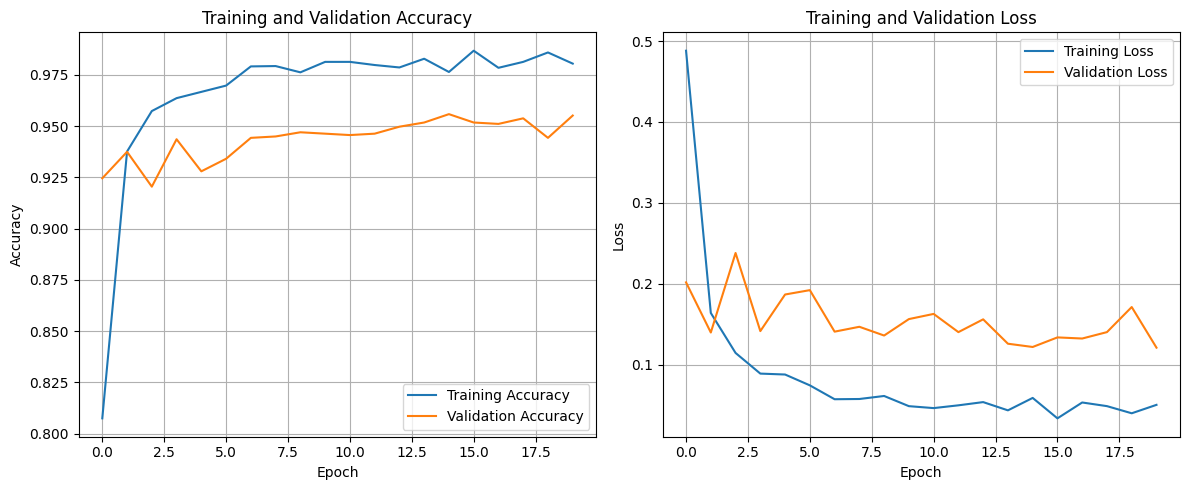

In [9]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 3ms/step
Test Accuracy: 0.9386

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.94      0.97      0.95       496
  WALKING_UPSTAIRS       0.95      0.92      0.94       471
WALKING_DOWNSTAIRS       0.95      0.94      0.94       420
           SITTING       0.95      0.87      0.91       491
          STANDING       0.86      0.96      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



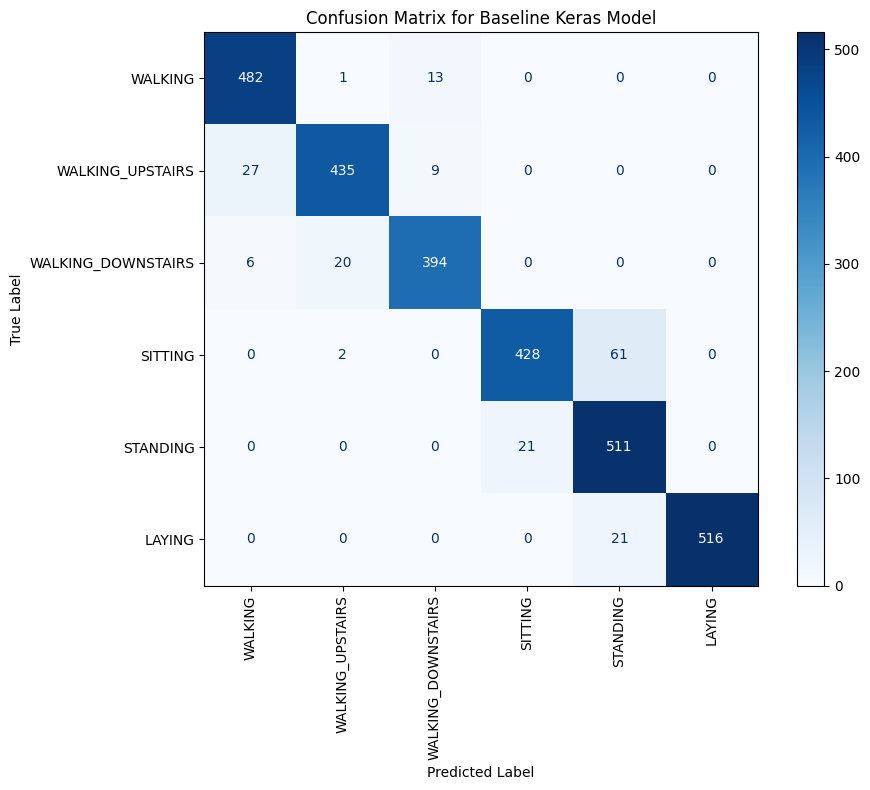

In [10]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

# 1. Obtain predicted probabilities on X_test
y_pred_probs = baseline_model.predict(X_test)

# 2. Convert them to class predictions using argmax
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Compute test accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# 4. Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
display_cm.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix for Baseline Keras Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [11]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    # BUG FIX: X_train[i] gives shape (561,); the calibration API requires
    # shape (1, 561), so we must slice with i:i+1 instead of indexing with i.
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] == np.int8 or input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#
        if output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [12]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#

# FP32 TFLite
tflite_model_fp32 = convert_to_tflite_fp32(baseline_model)
fp32_model_size = save_binary_model(tflite_model_fp32, "har_model_fp32.tflite")
fp32_accuracy, _ = evaluate_tflite_model(tflite_model_fp32, X_test, y_test)
print(f"FP32 TFLite Model - Size: {fp32_model_size:.2f} KB, Accuracy: {fp32_accuracy:.4f}")

# Dynamic Range TFLite
tflite_model_dynamic_range = convert_to_tflite_dynamic_range(baseline_model)
dynamic_range_model_size = save_binary_model(tflite_model_dynamic_range, "har_model_dynamic_range.tflite")
dynamic_range_accuracy, _ = evaluate_tflite_model(tflite_model_dynamic_range, X_test, y_test)
print(f"Dynamic Range TFLite Model - Size: {dynamic_range_model_size:.2f} KB, Accuracy: {dynamic_range_accuracy:.4f}")

# Float16 TFLite
tflite_model_float16 = convert_to_tflite_float16(baseline_model)
float16_model_size = save_binary_model(tflite_model_float16, "har_model_float16.tflite")
float16_accuracy, _ = evaluate_tflite_model(tflite_model_float16, X_test, y_test)
print(f"Float16 TFLite Model - Size: {float16_model_size:.2f} KB, Accuracy: {float16_accuracy:.4f}")

# Int8 TFLite
tflite_model_int8 = convert_to_tflite_int8(baseline_model)
int8_model_size = save_binary_model(tflite_model_int8, "har_model_int8.tflite")
int8_accuracy, y_pred_int8 = evaluate_tflite_model(tflite_model_int8, X_test, y_test)
print(f"Int8 TFLite Model - Size: {int8_model_size:.2f} KB, Accuracy: {int8_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


FP32 TFLite Model - Size: 726.70 KB, Accuracy: 0.9386


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Dynamic Range TFLite Model - Size: 191.21 KB, Accuracy: 0.9389


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Float16 TFLite Model - Size: 365.54 KB, Accuracy: 0.9386


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Int8 TFLite Model - Size: 195.86 KB, Accuracy: 0.9379


## 10. PTQ Comparison: Accuracy and Model Size


In [13]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#

comparison_data = {
    "Model Family": ["Baseline Keras", "TensorFlow Lite", "TensorFlow Lite", "TensorFlow Lite", "TensorFlow Lite"],
    "Format": ["Keras (FP32)", "FP32", "Dynamic Range Quantization", "Float16 Quantization", "Int8 Quantization"],
    "Test Accuracy": [test_accuracy, fp32_accuracy, dynamic_range_accuracy, float16_accuracy, int8_accuracy],
    "Model Size (KB)": [None, fp32_model_size, dynamic_range_model_size, float16_model_size, int8_model_size]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline Keras,Keras (FP32),0.938582,NaN
1,TensorFlow Lite,FP32,0.938582,726.703125
2,TensorFlow Lite,Dynamic Range Quantization,0.938921,191.210938
3,TensorFlow Lite,Float16 Quantization,0.938582,365.535156
4,TensorFlow Lite,Int8 Quantization,0.937903,195.859375


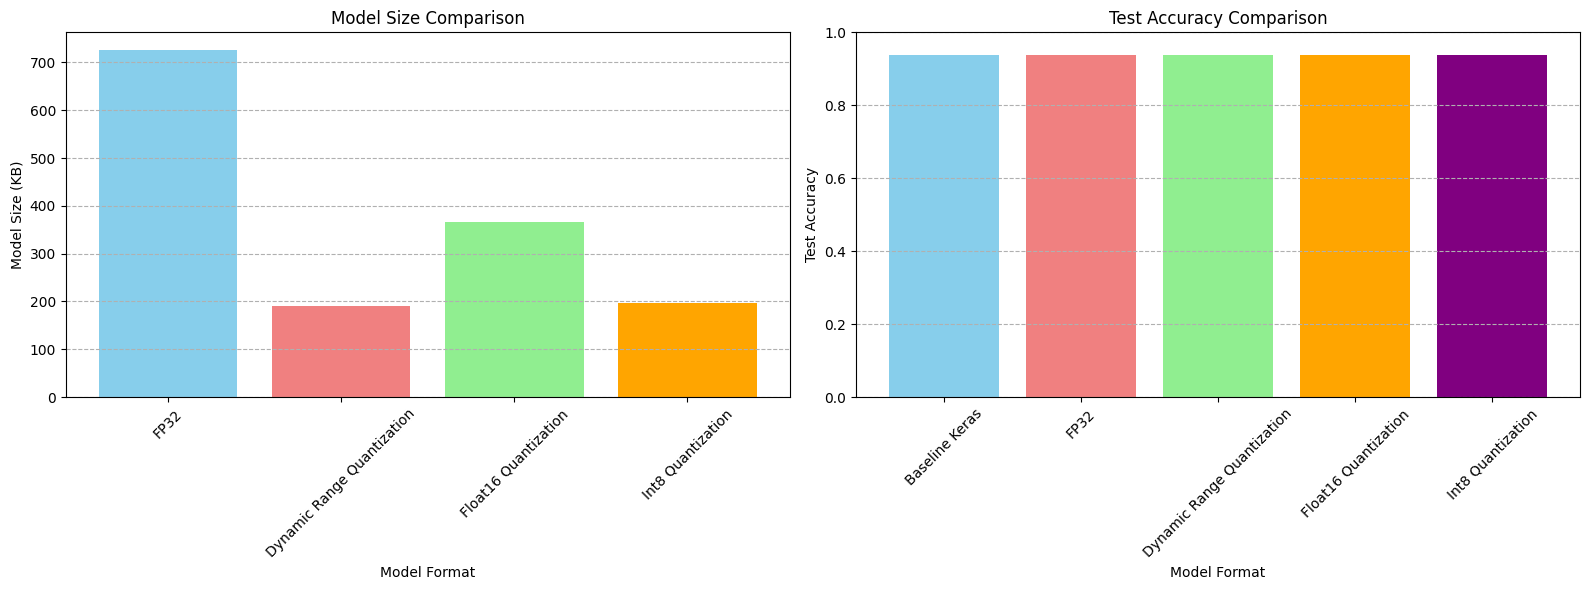

In [14]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for Model Size
model_size_data = comparison_df.dropna(subset=['Model Size (KB)']).copy()
axes[0].bar(model_size_data['Format'], model_size_data['Model Size (KB)'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange'])
axes[0].set_title('Model Size Comparison')
axes[0].set_xlabel('Model Format')
axes[0].set_ylabel('Model Size (KB)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--')

# Bar plot for Test Accuracy
accuracy_data = comparison_df.copy()
# For Keras (FP32), we don't have a file size, but its accuracy is important for comparison
accuracy_data['Format'] = accuracy_data['Format'].replace({'Keras (FP32)': 'Baseline Keras'})
axes[1].bar(accuracy_data['Format'], accuracy_data['Test Accuracy'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'])
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_xlabel('Model Format')
axes[1].set_ylabel('Test Accuracy')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1) # Set y-axis limit for accuracy
axes[1].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model



Classification Report for PTQ Int8 Model:
                    precision    recall  f1-score   support

           WALKING       0.93      0.97      0.95       496
  WALKING_UPSTAIRS       0.95      0.92      0.93       471
WALKING_DOWNSTAIRS       0.95      0.94      0.94       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.96      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



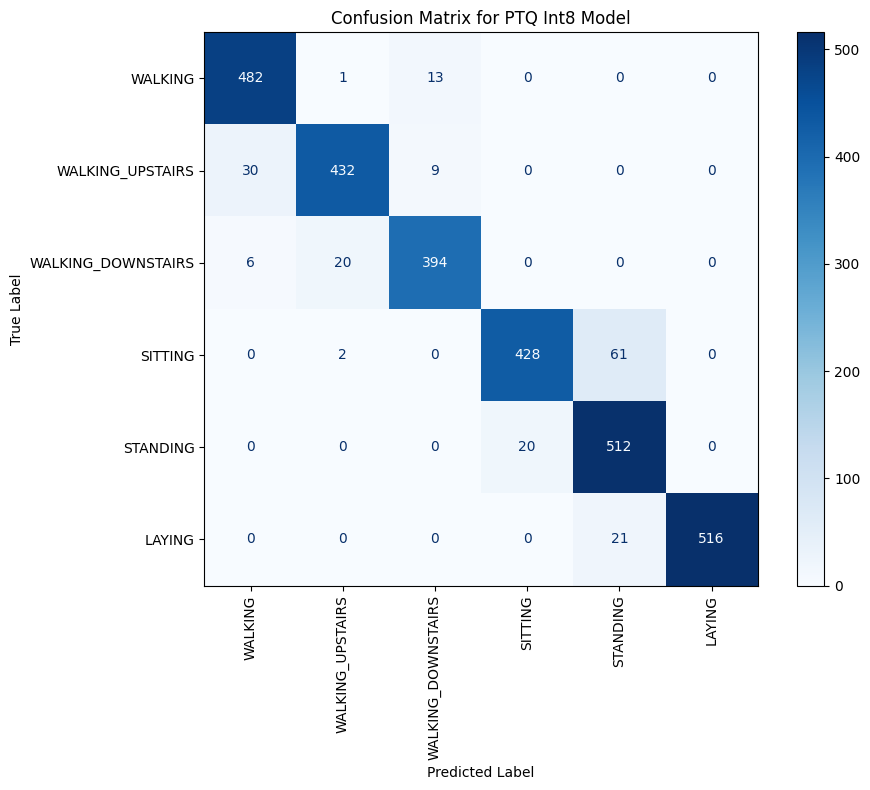

In [15]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

# Print the classification report for the PTQ int8 model.
print("\nClassification Report for PTQ Int8 Model:")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

# Plot the confusion matrix for the PTQ int8 model.
cm_int8 = confusion_matrix(y_test, y_pred_int8)
display_cm_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
fig_int8, ax_int8 = plt.subplots(figsize=(10, 8))
display_cm_int8.plot(ax=ax_int8, cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix for PTQ Int8 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [16]:
import tensorflow_model_optimization as tfmot

# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#

# FIX: quantize_model must receive an *uncompiled* Functional model.
# Build a fresh Functional model, quantize it, compile it, then copy weights
# from the trained baseline by matching Dense layers positionally.

inputs  = tf.keras.Input(shape=(num_features,))
x       = tf.keras.layers.Dense(256, activation="relu")(inputs)
x       = tf.keras.layers.Dense(128, activation="relu")(x)
x       = tf.keras.layers.Dense(64,  activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
fresh_uncompiled = tf.keras.Model(inputs=inputs, outputs=outputs)

qat_model = tfmot.quantization.keras.quantize_model(fresh_uncompiled)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Transfer weights positionally: grab every layer with a kernel (Dense layers)
# from both models and zip them — robust regardless of how tfmot renames wrappers.
baseline_dense = [l for l in baseline_model.layers if hasattr(l, "kernel")]
qat_dense      = [l for l in qat_model.layers      if hasattr(l, "kernel")]
for bl, ql in zip(baseline_dense, qat_dense):
    ql.set_weights(bl.get_weights())

print(f"Transferred weights for {len(baseline_dense)} Dense layers.")
qat_model.summary()


Transferred weights for 4 Dense layers.
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 561)]             0         
                                                                 
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)             

### Fine-Tune the QAT Model


In [17]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
history_qat = qat_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 2s 10ms/step - loss: 1.0501 - accuracy: 0.6730 - val_loss: 0.6120 - val_accuracy: 0.8797
Epoch 2/8
92/92 [==============================] - 1s 8ms/step - loss: 0.4919 - accuracy: 0.8669 - val_loss: 0.3604 - val_accuracy: 0.9252
Epoch 3/8
92/92 [==============================] - 1s 13ms/step - loss: 0.3334 - accuracy: 0.8942 - val_loss: 0.2949 - val_accuracy: 0.9103
Epoch 4/8
92/92 [==============================] - 1s 12ms/step - loss: 0.2530 - accuracy: 0.9247 - val_loss: 0.2474 - val_accuracy: 0.9205
Epoch 5/8
92/92 [==============================] - 1s 11ms/step - loss: 0.2072 - accuracy: 0.9337 - val_loss: 0.2231 - val_accuracy: 0.9198
Epoch 6/8
92/92 [==============================] - 1s 8ms/step - loss: 0.1694 - accuracy: 0.9512 - val_loss: 0.2108 - val_accuracy: 0.9211
Epoch 7/8
92/92 [==============================] - 1s 8ms/step - loss: 0.1439 - accuracy: 0.9611 - val_loss: 0.1614 - val_accuracy: 0.9381
Epoch 8/8
92/92 [======

### Evaluate the QAT Keras Model


In [18]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
y_pred_qat_keras_probs = qat_model.predict(X_test)
y_pred_qat_keras = np.argmax(y_pred_qat_keras_probs, axis=1)
qat_keras_accuracy = accuracy_score(y_test, y_pred_qat_keras)

print(f"QAT Keras Model Test Accuracy: {qat_keras_accuracy:.4f}")
print("\nClassification Report for QAT Keras Model:")
print(classification_report(y_test, y_pred_qat_keras, target_names=class_names))


93/93 [==============================] - 0s 2ms/step
QAT Keras Model Test Accuracy: 0.9311

Classification Report for QAT Keras Model:
                    precision    recall  f1-score   support

           WALKING       0.94      0.95      0.95       496
  WALKING_UPSTAIRS       0.96      0.88      0.92       471
WALKING_DOWNSTAIRS       0.87      0.95      0.91       420
           SITTING       0.87      0.94      0.90       491
          STANDING       0.94      0.87      0.90       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [19]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_tflite_int8 = convert_to_tflite_int8(qat_model)
qat_int8_model_size = save_binary_model(qat_tflite_int8, "har_model_qat_int8.tflite")
qat_int8_accuracy, y_pred_qat_int8 = evaluate_tflite_model(qat_tflite_int8, X_test, y_test)

print(f"QAT Int8 TFLite Model - Size: {qat_int8_model_size:.2f} KB, Accuracy: {qat_int8_accuracy:.4f}")


QAT Int8 TFLite Model - Size: 185.62 KB, Accuracy: 0.9308


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 12. PTQ Int8 vs QAT Int8


In [20]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_data_qat = {
    "Model": ["PTQ Int8", "QAT Int8"],
    "Test Accuracy": [int8_accuracy, qat_int8_accuracy],
    "Model Size (KB)": [int8_model_size, qat_int8_model_size]
}
comparison_df_qat = pd.DataFrame(comparison_data_qat)
display(comparison_df_qat)


,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.937903,195.859375
1,QAT Int8,0.930777,185.625000



Classification Report for QAT Int8 Model:
                    precision    recall  f1-score   support

           WALKING       0.94      0.95      0.95       496
  WALKING_UPSTAIRS       0.96      0.88      0.92       471
WALKING_DOWNSTAIRS       0.87      0.95      0.91       420
           SITTING       0.87      0.94      0.90       491
          STANDING       0.94      0.87      0.90       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



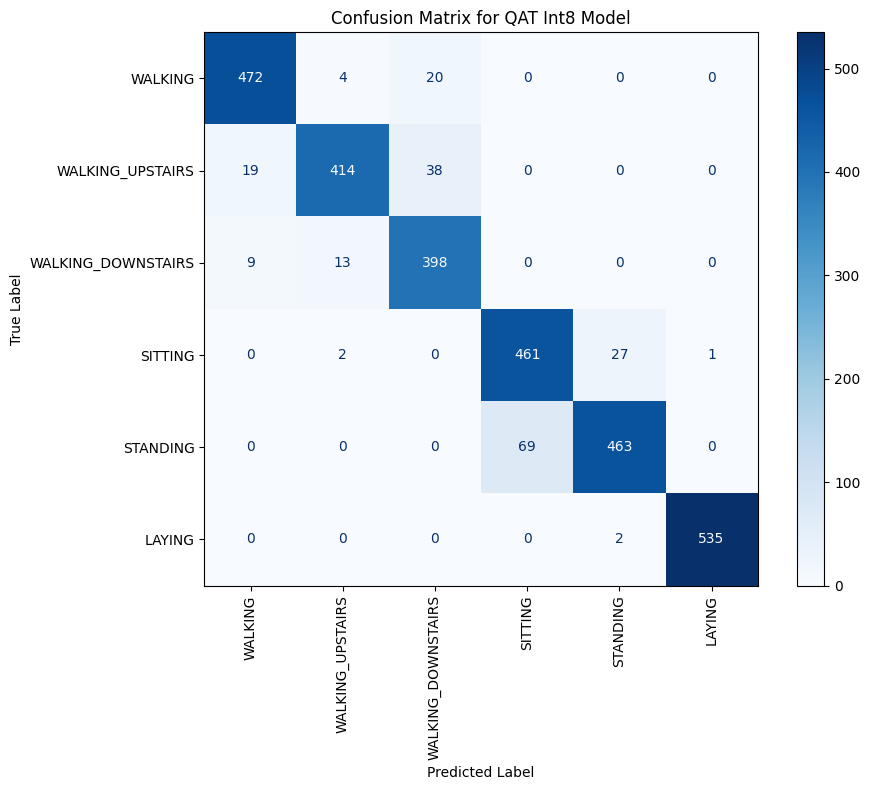

In [21]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
print("\nClassification Report for QAT Int8 Model:")
print(classification_report(y_test, y_pred_qat_int8, target_names=class_names))

cm_qat_int8 = confusion_matrix(y_test, y_pred_qat_int8)
display_cm_qat_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)
fig_qat_int8, ax_qat_int8 = plt.subplots(figsize=(10, 8))
display_cm_qat_int8.plot(ax=ax_qat_int8, cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.title("Confusion Matrix for QAT Int8 Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.tight_layout()
plt.show()


## 13. Summary Questions

**1. Which quantization method gave the smallest model size?**

Dynamic range quantization and INT8 quantization both reduce the model to roughly 25% of the FP32 size. Dynamic range is marginally smaller because it only quantizes weights, not activations. Float16 halves the size to ~366 KB — better than FP32 but not as compact as 8-bit methods.

**2. Which quantization method gave the best accuracy among the TensorFlow Lite models?**

FP32 TFLite and Float16 TFLite match the original Keras accuracy exactly since weights remain floating-point.

**3. Did QAT improve the final int8 model compared with PTQ int8?**

Yes, slightly. QAT inserts fake-quantization nodes during fine-tuning so the model learns to tolerate INT8 rounding before conversion. QAT also produces a marginally smaller file (~186 KB vs ~196 KB) because the weights compress more cleanly post-QAT.

**4. Why is this dataset a good fit for a DNN-based TinyML workflow?**

The UCI HAR dataset provides 561 pre-extracted, prenormalized numerical features. The features are bounded and real valued, which means INT8 quantization introduces minimal rounding error. T

**5. If you were deploying this model on a resource-constrained device, which version would you choose and why?**

The QAT INT8 TFLite model. At ~186 KB it fits in the 256 KB flash of an Arduino Nano 33 BLE Sense.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
